## Classifier Comparison: MLP vs Regression
 
This notebook compares the performance of different classifiers on the fMRI dataset, focusing on Multi-Layer Perceptron (MLP) and linear regression models.

#### Objectives
- Load the processed fMRI data and prepare it for classification tasks.
- Train multiple classifiers (MLP, regression) on the training data.
- Evaluate each model on the test set.
- Compare the results and visualize performance differences.
- Discuss findings and implications for fMRI decoding.

#### Outputs
- Evaluation metrics and performance comparison
- Visualizations of results
- Summary and interpretation of findings

## 1. Import Libraries and Load Data

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

output_dir = os.path.abspath(os.path.join("..", "outputs", "processed"))
X_train = np.load(os.path.join(output_dir, "X_train_pca.npy"))
X_test = np.load(os.path.join(output_dir, "X_test_pca.npy"))
y_train = np.load(os.path.join(output_dir, "y_train.npy"))
y_test = np.load(os.path.join(output_dir, "y_test.npy"))

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 2. Construct MLP

In [2]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classed):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classed)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

input_dim = X_train.shape[1]
hidden_dim = 100
num_classes = len(np.unique(y_train))
mlp_model = MLP(input_dim, hidden_dim, num_classes)

## 3. Training & Evaluation

In [3]:
# Train the model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)
num_epochs = 20
mlp_losses = []

for epoch in range(num_epochs):
    mlp_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = mlp_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        mlp_losses.append(loss.item())
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
mlp_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = mlp_model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
print(f"Accuracy of the model on the test set: {100 * correct / total:.2f}%") 

Epoch [1/20], Loss: 0.0169
Epoch [2/20], Loss: 0.0000
Epoch [3/20], Loss: 0.0000
Epoch [4/20], Loss: 0.0000
Epoch [5/20], Loss: 0.0000
Epoch [6/20], Loss: 0.0011
Epoch [7/20], Loss: 0.0006
Epoch [8/20], Loss: 0.0000
Epoch [9/20], Loss: 0.0000
Epoch [10/20], Loss: 0.0000
Epoch [11/20], Loss: 0.0000
Epoch [12/20], Loss: 0.0000
Epoch [13/20], Loss: 0.0000
Epoch [14/20], Loss: 0.0000
Epoch [15/20], Loss: 0.0000
Epoch [16/20], Loss: 0.0000
Epoch [17/20], Loss: 0.0000
Epoch [18/20], Loss: 0.0000
Epoch [19/20], Loss: 0.0000
Epoch [20/20], Loss: 0.0000
Accuracy of the model on the test set: 100.00%


## 4. Logistic Regression

In [4]:
# Define and train a Logistic Regression model for comparison
class LR(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    
    def forward(self, x):
        return self.linear(x)

# Train the Logistic Regression model
lr_model = LR(input_dim, num_classes)
optimizer = optim.Adam(lr_model.parameters(), lr=0.001)
lr_losses = []

for epoch in range(num_epochs):
    lr_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = lr_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        lr_losses.append(loss.item())
        optimizer.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the Logistic Regression model
lr_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = lr_model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
print(f"Accuracy of the Logistic Regression model on the test set: {100 * correct / total:.2f}%")

Epoch [1/20], Loss: 1.6447
Epoch [2/20], Loss: 0.0020
Epoch [3/20], Loss: 1.6091
Epoch [4/20], Loss: 0.0002
Epoch [5/20], Loss: 0.0001
Epoch [6/20], Loss: 0.0000
Epoch [7/20], Loss: 0.0002
Epoch [8/20], Loss: 0.0001
Epoch [9/20], Loss: 0.0010
Epoch [10/20], Loss: 0.0009
Epoch [11/20], Loss: 0.0000
Epoch [12/20], Loss: 0.0000
Epoch [13/20], Loss: 0.0001
Epoch [14/20], Loss: 0.0000
Epoch [15/20], Loss: 0.0002
Epoch [16/20], Loss: 0.0000
Epoch [17/20], Loss: 0.0000
Epoch [18/20], Loss: 0.0000
Epoch [19/20], Loss: 0.0007
Epoch [20/20], Loss: 0.0000
Accuracy of the Logistic Regression model on the test set: 99.67%


## 5. Performance Plot

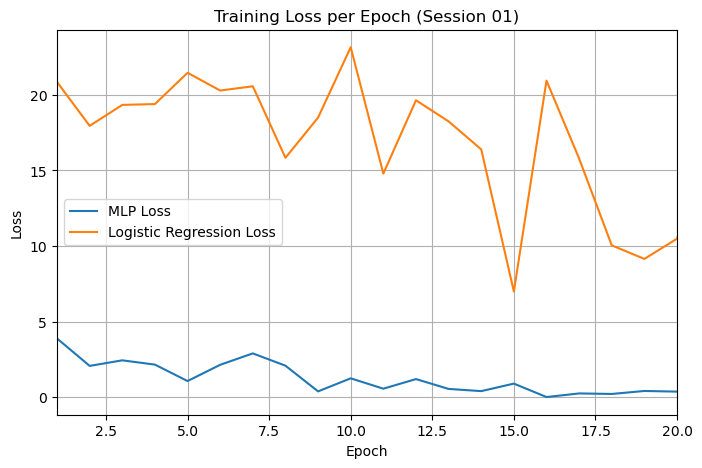

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mlp_losses)+1), mlp_losses, label='MLP Loss')
plt.plot(range(1, len(lr_losses)+1), lr_losses, label='Logistic Regression Loss')
plt.xlim(1, num_epochs)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch (Session 01)')
plt.legend()
plt.grid(True)
plt.show()

## 6. Generalize to New Sessions

In [3]:
import os
import numpy as np
import nibabel as nib
from tqdm import tqdm

data_dir = os.path.abspath(os.path.join("..", "data", "subj01"))
output_dir = os.path.abspath(os.path.join("..", "outputs", "processed"))

# Import betas for sessions 2 and 3
beta_s2 = nib.load(os.path.join(data_dir, "betas_session02.nii.gz"))
beta_s3 = nib.load(os.path.join(data_dir, "betas_session03.nii.gz"))

# Reload mask
resampled_mask = np.load(os.path.join(output_dir, "resampled_mask.npy"))
def masked_trials(img, mask):
    n_trials = img.shape[3]
    for i in tqdm(range(n_trials), desc="Extracting masked trials"):
        yield img.dataobj[..., i][mask]

# Save masked data for sessions 2 and 3
X_nat_s2 = np.stack([trial for trial in masked_trials(beta_s2, resampled_mask)])
X_nat_s3 = np.stack([trial for trial in masked_trials(beta_s3, resampled_mask)])

np.save(os.path.join(output_dir, 'X_nat_s2.npy'), X_nat_s2)
np.save(os.path.join(output_dir, 'X_nat_s3.npy'), X_nat_s3)

Extracting masked trials: 100%|██████████| 750/750 [17:26<00:00,  1.40s/it]


In [12]:
# Restart kernel to save RAM, and then run the following code to load all masked data and perform PCA
import os
import numpy as np
import torch
import joblib
import scipy.io as sio

output_dir = os.path.abspath(os.path.join("..", "outputs", "processed"))
# Load masked data for session 2 and 3
X_syn = np.load(os.path.join(output_dir, "X_syn.npy"))
X_nat_s2 = np.load(os.path.join(output_dir, "X_nat_s2.npy"))
X_nat_s3 = np.load(os.path.join(output_dir, "X_nat_s3.npy"))
X_train = np.load(os.path.join(output_dir, "X_train.npy"))
X_test = np.load(os.path.join(output_dir, "X_test.npy"))

# Combine sessions and create labels
X_all = np.concatenate([X_syn, X_nat_s2, X_nat_s3], axis=0)
y_all = np.concatenate([
    np.ones(X_syn.shape[0]),
    np.zeros(X_nat_s2.shape[0] + X_nat_s3.shape[0])
])

# Load saved PCA components for scaling
X_train_mean = np.load(os.path.join(output_dir, "X_train_mean.npy"))
X_train_std = np.load(os.path.join(output_dir, "X_train_std.npy"))
PCs = np.load(os.path.join(output_dir, "PCs.npy"))

X_all_scaled = (X_all - X_train_mean) / X_train_std
X_all_pca = X_all_scaled @ PCs

np.save(os.path.join(output_dir, "X_all_pca.npy"), X_all_pca)
np.save(os.path.join(output_dir, "y_all.npy"), y_all)


C:\Users\techt\AppData\Local\Temp\ipykernel_17268\775555495.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


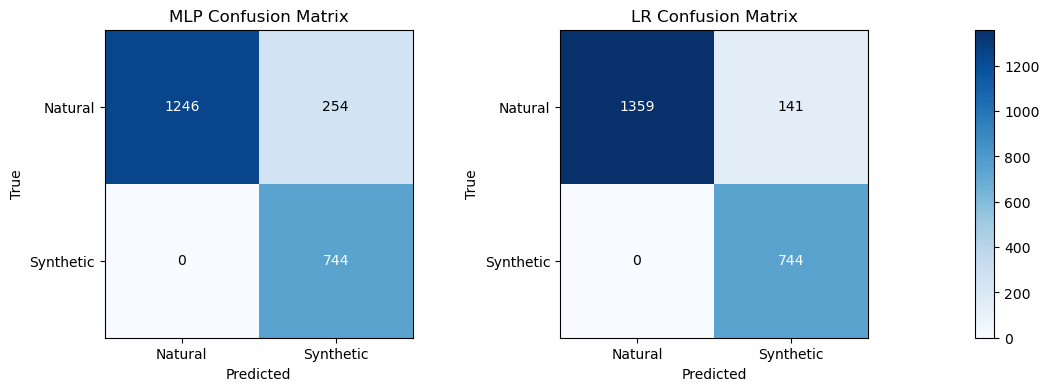

In [54]:
# Load PCA data and shuffle
X_all_pca = np.load(os.path.join(output_dir, "X_all_pca.npy"))
perm = np.random.permutation(X_all_pca.shape[0])
X_all_pca_shuffled = X_all_pca[perm]
y_all_shuffled = y_all[perm]

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_all_pca_shuffled, dtype=torch.float32)
y_tensor = torch.tensor(y_all_shuffled, dtype=torch.long)

# Evaluate models on all sessions
mlp_model.eval()
lr_model.eval()
with torch.no_grad():
    mlp_pred = torch.argmax(mlp_model(X_tensor), dim=1).cpu().numpy()
    lr_pred = torch.argmax(lr_model(X_tensor), dim=1).cpu().numpy()
    y_true = y_tensor.cpu().numpy()

# Confusion matrix
def manual_confusion_matrix(y_true, y_pred, n_classes=2):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

# Plot confusion matrix
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(cm.shape[0])
    plt.xticks(tick_marks, ['Natural', 'Synthetic'])
    plt.yticks(tick_marks, ['Natural', 'Synthetic'])
    plt.xlabel('Predicted')
    plt.ylabel('True')

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()

# Compute and plot confusion matrices
# Plot both confusion matrices side by side
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.25)

ax0 = plt.subplot(gs[0])
ax1 = plt.subplot(gs[1])
cax = plt.subplot(gs[2])

for ax, cm, title in zip([ax0, ax1], [cm_mlp, cm_lr], ["MLP Confusion Matrix", "LR Confusion Matrix"]):
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=max(cm_mlp.max(), cm_lr.max()))
    ax.set_title(title)
    tick_marks = np.arange(cm.shape[0])
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(['Natural', 'Synthetic'])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(['Natural', 'Synthetic'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

# Add colorbar in its own axis
plt.colorbar(im, cax=cax)
plt.tight_layout()
plt.show()

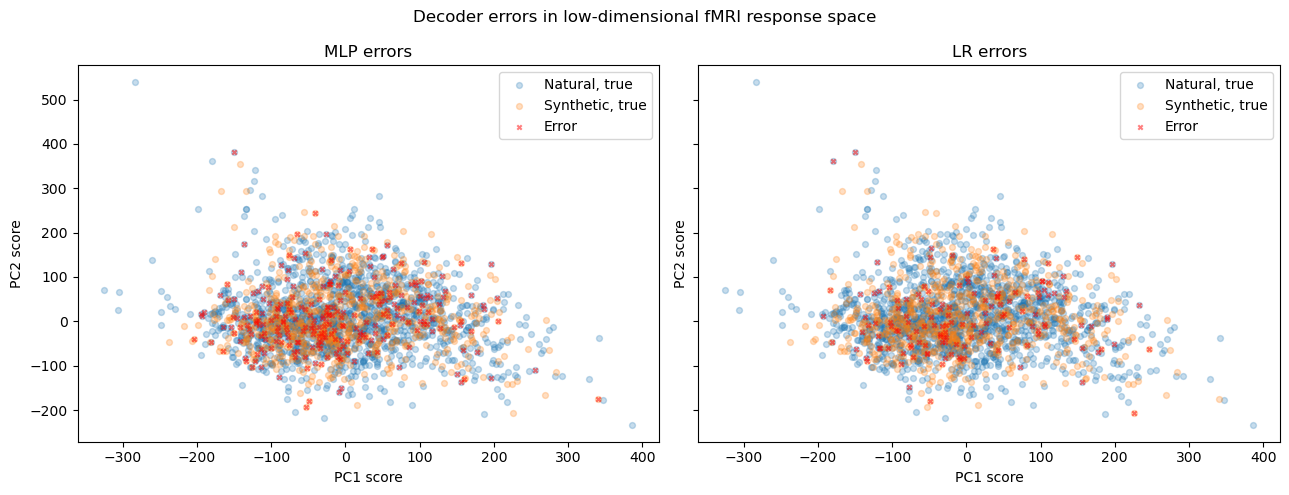

In [68]:
# Better visualization of errors projected onto PCA space
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

models = [
    ("MLP errors", mlp_wrong, axes[0]),
    ("LR errors", lr_wrong, axes[1])
]

for title, wrong, ax in models:
    ax.scatter(
        X_all_pca[y_true == 0, 0],
        X_all_pca[y_true == 0, 1],
        s=18,
        alpha=0.25,
        label="Natural, true"
    )
    ax.scatter(
        X_all_pca[y_true == 1, 0],
        X_all_pca[y_true == 1, 1],
        s=18,
        alpha=0.25,
        label="Synthetic, true"
    )
    ax.scatter(
        X_all_pca[wrong, 0],
        X_all_pca[wrong, 1],
        s=10,
        c="r",
        marker="x",
        alpha=0.5,
        label="Error"
    )

    ax.set_title(title)
    ax.set_xlabel("PC1 score")
    ax.set_ylabel("PC2 score")
    ax.legend()

plt.suptitle("Decoder errors in low-dimensional fMRI response space")
plt.tight_layout()
plt.show()

#### Findings

Both models make most of their errors in the central region of the PC1 and PC2 space, where natural and synthetic trials visibly overlap. This suggests that decoder failures occur mainly for trials whose low dimensional response patterns are ambiguous between the two stimulus conditions. The result supports the idea that natural and synthetic responses are partially separable, but not completely distinct, in the first two neural PCs, which is consistent with prior PCA analysis.

The MLP shows a denser and broader distribution of errors than logistic regression. Logistic regression produces fewer error points while showing a similar overall error geometry. This matches the confusion matrix results, where logistic regression made fewer false synthetic predictions on natural trials.

The stronger generalization of logistic regression suggests that the stable natural versus synthetic distinction in this PCA reduced fMRI space may be captured by a relatively simple linear boundary. In contrast, the MLP may have been overfitted during training with single session data.